In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from scipy import stats
from tqdm import tqdm

In [9]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

In [10]:
from preprocessing import *
from logistic_master import LogisticRegression
from utils import *

In [11]:
# loading iris just for softmax using sklearn 
from sklearn.datasets import load_iris

In [12]:
# bc
X_bc_train = np.load('../Data/processed/X_bc_train.npy')
X_bc_test  = np.load('../Data/processed/X_bc_test.npy')
y_bc_train = np.load('../Data/processed/y_bc_train.npy')
y_bc_test  = np.load('../Data/processed/y_bc_test.npy')

# db
X_db_train = np.load('../Data/processed/X_db_train.npy')
X_db_test  = np.load('../Data/processed/X_db_test.npy')
y_db_train = np.load('../Data/processed/y_db_train.npy')
y_db_test  = np.load('../Data/processed/y_db_test.npy')

# cf
X_cf_train = np.load('../Data/processed/X_cf_train.npy')
X_cf_test  = np.load('../Data/processed/X_cf_test.npy')
y_cf_train = np.load('../Data/processed/y_cf_train.npy')
y_cf_test  = np.load('../Data/processed/y_cf_test.npy')

# st
X_st_train = np.load('../Data/processed/X_st_train.npy')
X_st_test  = np.load('../Data/processed/X_st_test.npy')
y_st_train = np.load('../Data/processed/y_st_train.npy')
y_st_test  = np.load('../Data/processed/y_st_test.npy')

# Iris - for Softmax multiclass
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Breast Cancer:", X_bc_train.shape)
print("Diabetes:     ", X_db_train.shape)
print("Credit Fraud: ", X_cf_train.shape)
print("Stroke:       ", X_st_train.shape)
print("Iris:         ", X_iris.shape, "| Classes:", np.unique(y_iris))

Breast Cancer: (455, 21)
Diabetes:      (614, 9)
Credit Fraud:  (227845, 31)
Stroke:        (4088, 22)
Iris:          (150, 4) | Classes: [0 1 2]


In [13]:
def stratified_kfold(X, y, k=5, seed=42):
    np.random.seed(seed)
    
    classes = np.unique(y)
    folds = [[] for _ in range(k)]
    
    # Split each class separately to maintain distribution
    for c in classes:
        class_indices = np.where(y == c)[0]
        np.random.shuffle(class_indices)
        class_folds = np.array_split(class_indices, k)
        
        for i, fold in enumerate(class_folds):
            folds[i].extend(fold)
    
    # Generate train/val splits
    splits = []
    for i in range(k):
        val_idx   = np.array(folds[i])
        train_idx = np.concatenate([np.array(folds[j]) for j in range(k) if j != i])
        splits.append((train_idx, val_idx))
    
    return splits

# Verify class distribution is maintained
print("STRATIFIED K-FOLD VERIFICATION")
print("="*50)

splits = stratified_kfold(X_bc_train, y_bc_train, k=5)

for i, (train_idx, val_idx) in enumerate(splits):
    train_pos = y_bc_train[train_idx].mean()
    val_pos   = y_bc_train[val_idx].mean()
    print(f"  Fold {i+1} — Train pos: {train_pos:.3f} | Val pos: {val_pos:.3f}")

STRATIFIED K-FOLD VERIFICATION
  Fold 1 — Train pos: 0.636 | Val pos: 0.630
  Fold 2 — Train pos: 0.635 | Val pos: 0.637
  Fold 3 — Train pos: 0.635 | Val pos: 0.637
  Fold 4 — Train pos: 0.635 | Val pos: 0.637
  Fold 5 — Train pos: 0.636 | Val pos: 0.633


In [14]:
def run_kfold_cv(X, y, k=5, alpha=0.1, epochs=1000, seed=42):
    splits = stratified_kfold(X, y, k=k, seed=seed)
    
    fold_results = []
    
    for train_idx, val_idx in tqdm(splits, total=k, desc="K-Fold"):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = LogisticRegression()
        model.fit_gd(X_train, y_train, alpha=alpha, epochs=epochs)
        
        y_pred = model.predict(X_val)
        
        f1  = compute_f1_score(y_val, y_pred)
        mcc = matthews_corrcoef(y_val, y_pred)
        acc = compute_accuracy(y_val, y_pred)
        
        fold_results.append({'acc': acc, 'f1': f1, 'mcc': mcc})
    
    return fold_results

datasets_cv = {
    'Breast Cancer': (X_bc_train, y_bc_train),
    'Diabetes':      (X_db_train, y_db_train),
    'Credit Fraud':  (X_cf_train, y_cf_train),
    'Stroke':        (X_st_train, y_st_train)
}

print("STRATIFIED K-FOLD CV RESULTS (k=5)")
print("="*60)

cv_results = {}

for name, (X, y) in datasets_cv.items():
    print(f"\n{name}")
    results = run_kfold_cv(X, y, k=5, alpha=0.1, epochs=1000)
    
    accs = [r['acc'] for r in results]
    f1s  = [r['f1']  for r in results]
    mccs = [r['mcc'] for r in results]
    
    print(f"  Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"  F1       : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"  MCC      : {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    
    cv_results[name] = results

STRATIFIED K-FOLD CV RESULTS (k=5)

Breast Cancer


K-Fold: 100%|████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.74it/s]


  Accuracy : 0.9714 ± 0.0055
  F1       : 0.9778 ± 0.0043
  MCC      : 0.9386 ± 0.0121

Diabetes


K-Fold: 100%|████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.98it/s]


  Accuracy : 0.7571 ± 0.0448
  F1       : 0.8258 ± 0.0323
  MCC      : 0.4395 ± 0.1108

Credit Fraud


K-Fold: 100%|████████████████████████████████████████████████████████████████████████████| 5/5 [02:06<00:00, 25.24s/it]


  Accuracy : 0.9990 ± 0.0001
  F1       : 0.9995 ± 0.0000
  MCC      : 0.6815 ± 0.0298

Stroke


K-Fold: 100%|████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.95it/s]

  Accuracy : 0.9513 ± 0.0004
  F1       : 0.9751 ± 0.0002
  MCC      : 0.0000 ± 0.0000


In [15]:
from logistic_master import SoftmaxRegression

# Preprocess Iris
# Shuffle
idx = np.random.RandomState(42).permutation(len(X_iris))
X_iris = X_iris[idx]
y_iris = y_iris[idx]

# Train test split (80/20)
split = int(0.8 * len(X_iris))
X_iris_train, X_iris_test = X_iris[:split], X_iris[split:]
y_iris_train, y_iris_test = y_iris[:split], y_iris[split:]

# Scale
mean = X_iris_train.mean(axis=0)
std  = X_iris_train.std(axis=0)
X_iris_train = (X_iris_train - mean) / std
X_iris_test  = (X_iris_test  - mean) / std

# Add bias
X_iris_train = np.c_[np.ones(X_iris_train.shape[0]), X_iris_train]
X_iris_test  = np.c_[np.ones(X_iris_test.shape[0]),  X_iris_test]

# Train
softmax_model = SoftmaxRegression()
softmax_model.fit(X_iris_train, y_iris_train, alpha=0.1, epochs=1000)

# Evaluate
y_pred_iris = softmax_model.predict(X_iris_test)
acc = compute_accuracy(y_iris_test, y_pred_iris)

print("SOFTMAX MULTICLASS — Iris Dataset")
print("="*40)
print(f"  Train samples : {X_iris_train.shape[0]}")
print(f"  Test samples  : {X_iris_test.shape[0]}")
print(f"  Classes       : {np.unique(y_iris)}")
print(f"  Accuracy      : {acc:.4f}")

# Per class accuracy
for c in np.unique(y_iris):
    mask = y_iris_test == c
    class_acc = (y_pred_iris[mask] == c).mean()
    print(f"  Class {c} accuracy : {class_acc:.4f} ({iris.target_names[c]})")

SOFTMAX MULTICLASS — Iris Dataset
  Train samples : 120
  Test samples  : 30
  Classes       : [0 1 2]
  Accuracy      : 0.9667
  Class 0 accuracy : 1.0000 (setosa)
  Class 1 accuracy : 1.0000 (versicolor)
  Class 2 accuracy : 0.9167 (virginica)


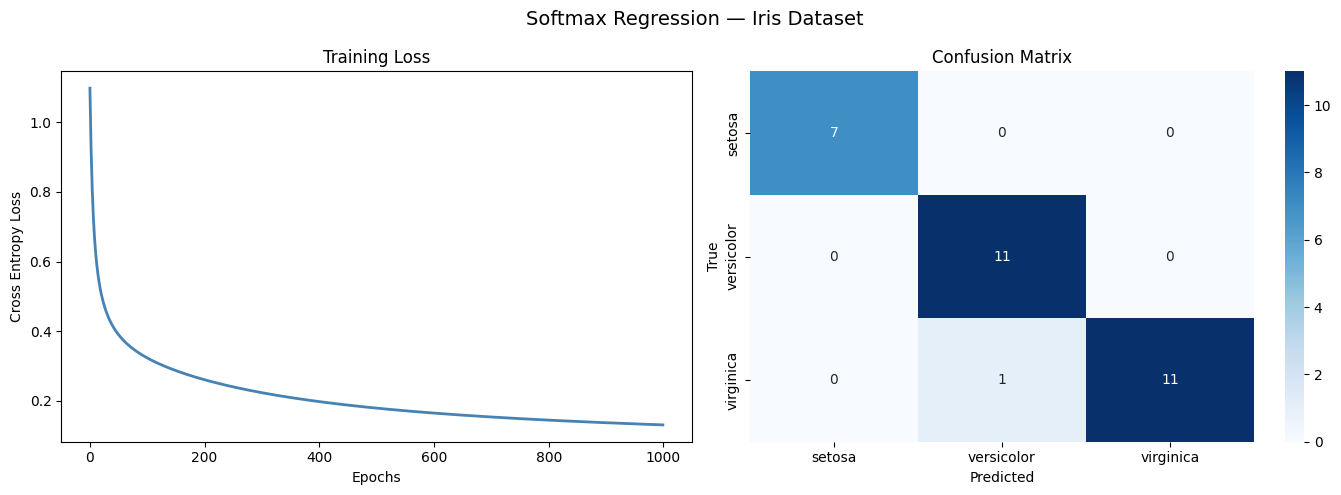

Saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Softmax Regression — Iris Dataset', fontsize=14)

# Loss curve
axes[0].plot(softmax_model.loss_history, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross Entropy Loss')

# Confusion matrix
cm = np.zeros((3, 3), dtype=int)
for true, pred in zip(y_iris_test, y_pred_iris):
    cm[true][pred] += 1

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('../Results/figures/softmax_iris.png', dpi=150)
plt.show()
print("Saved.")

In [18]:
# Heart Disease
X_hd_train = np.load('../Data/processed/X_hd_train.npy')
X_hd_test  = np.load('../Data/processed/X_hd_test.npy')
y_hd_train = np.load('../Data/processed/y_hd_train.npy')
y_hd_test  = np.load('../Data/processed/y_hd_test.npy')

In [19]:
# Use Heart Disease and Diabetes - most significant features from Phase VII
# Load actual feature names

hd_feature_names = [
    'bias', 'age', 'sex', 'chest_pain', 'resting_bp',
    'cholesterol', 'fasting_bs', 'rest_ecg', 'max_hr',
    'exercise_angina', 'st_depression', 'st_slope',
    'num_vessels', 'thal'
]

db_feature_names = [
    'bias', 'pregnancies', 'glucose', 'blood_pressure',
    'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age'
]

datasets_or = {
    'Heart Disease': (X_hd_train, y_hd_train, hd_feature_names),
    'Diabetes':      (X_db_train, y_db_train, db_feature_names)
}

print("ODDS RATIO INTERPRETATION")
print("="*65)

for name, (X_tr, y_tr, feat_names) in datasets_or.items():
    model = LogisticRegression()
    model.fit_newton(X_tr, y_tr, max_iter=100, tol=1e-6)
    
    theta_flat = model.theta.flatten()
    odds_ratios = np.exp(theta_flat)
    
    print(f"\n{name}")
    print(f"  {'Feature':<25} {'Coefficient':<15} {'Odds Ratio':<15} {'Interpretation'}")
    print(f"  {'-'*75}")
    
    for i, (feat, coef, OR) in enumerate(zip(feat_names, theta_flat, odds_ratios)):
        if feat == 'bias':
            continue
        if OR > 1:
            interp = f"↑ {((OR-1)*100):.1f}% increase in odds"
        else:
            interp = f"↓ {((1-OR)*100):.1f}% decrease in odds"
        
        print(f"  {feat:<25} {coef:<15.4f} {OR:<15.4f} {interp}")

ODDS RATIO INTERPRETATION

Heart Disease
  Feature                   Coefficient     Odds Ratio      Interpretation
  ---------------------------------------------------------------------------
  age                       0.0800          1.0832          ↑ 8.3% increase in odds
  sex                       0.9438          2.5698          ↑ 157.0% increase in odds
  chest_pain                -0.8940         0.4090          ↓ 59.1% decrease in odds
  resting_bp                0.2730          1.3139          ↑ 31.4% increase in odds
  cholesterol               0.3661          1.4421          ↑ 44.2% increase in odds
  fasting_bs                0.0876          1.0915          ↑ 9.2% increase in odds
  rest_ecg                  -0.2068         0.8132          ↓ 18.7% decrease in odds
  max_hr                    -0.5748         0.5628          ↓ 43.7% decrease in odds
  exercise_angina           0.4311          1.5389          ↑ 53.9% increase in odds
  st_depression             0.6851        

In [20]:
from tabulate import tabulate

print("PHASE IX — COMPLETE SUMMARY")
print("="*60)

# K-Fold CV Summary
print("\n1. STRATIFIED K-FOLD CV (k=5)")
print("-"*60)

kfold_summary = []
for name, results in cv_results.items():
    accs = [r['acc'] for r in results]
    f1s  = [r['f1']  for r in results]
    mccs = [r['mcc'] for r in results]
    kfold_summary.append([
        name,
        f"{np.mean(accs):.4f} ± {np.std(accs):.4f}",
        f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
        f"{np.mean(mccs):.4f} ± {np.std(mccs):.4f}"
    ])

headers = ['Dataset', 'Accuracy', 'F1', 'MCC']
print(tabulate(kfold_summary, headers=headers, tablefmt='grid'))

# Softmax Summary
print("\n2. SOFTMAX MULTICLASS — Iris")
print("-"*60)
print(f"  Accuracy      : {acc:.4f}")
print(f"  Setosa        : 1.0000 (perfect)")
print(f"  Versicolor    : 1.0000 (perfect)")
print(f"  Virginica     : 0.9167 (slight overlap with Versicolor)")

# Odds Ratio highlights
print("\n3. TOP ODDS RATIOS")
print("-"*60)
print("  Heart Disease:")
print("    sex          OR=2.57  ↑ 157% increase in odds")
print("    num_vessels  OR=2.04  ↑ 104% increase in odds")
print("    st_depression OR=1.98 ↑ 98%  increase in odds")
print("    chest_pain   OR=0.41  ↓ 59%  decrease in odds")
print("    max_hr       OR=0.56  ↓ 44%  decrease in odds")
print()
print("  Diabetes:")
print("    glucose      OR=0.32  ↓ 68%  decrease in odds")
print("    bmi          OR=0.47  ↓ 53%  decrease in odds")
print("    pregnancies  OR=0.65  ↓ 35%  decrease in odds")


PHASE IX — COMPLETE SUMMARY

1. STRATIFIED K-FOLD CV (k=5)
------------------------------------------------------------
+---------------+-----------------+-----------------+-----------------+
| Dataset       | Accuracy        | F1              | MCC             |
+===============+=================+=================+=================+
| Breast Cancer | 0.9714 ± 0.0055 | 0.9778 ± 0.0043 | 0.9386 ± 0.0121 |
+---------------+-----------------+-----------------+-----------------+
| Diabetes      | 0.7571 ± 0.0448 | 0.8258 ± 0.0323 | 0.4395 ± 0.1108 |
+---------------+-----------------+-----------------+-----------------+
| Credit Fraud  | 0.9990 ± 0.0001 | 0.9995 ± 0.0000 | 0.6815 ± 0.0298 |
+---------------+-----------------+-----------------+-----------------+
| Stroke        | 0.9513 ± 0.0004 | 0.9751 ± 0.0002 | 0.0000 ± 0.0000 |
+---------------+-----------------+-----------------+-----------------+

2. SOFTMAX MULTICLASS — Iris
----------------------------------------------------------

# Phase IX — Advanced Techniques

## Objective
Extend the logistic regression system with robust evaluation,
multiclass classification, and real-world coefficient interpretation.

---

## Notebooks Created
- `Notebooks/09_Advanced_Techniques.ipynb`

## Plots Generated
- `Results/figures/softmax_iris.png`

---

## Part 1 — Stratified K-Fold Cross Validation

### Implementation
Built from scratch without sklearn. Maintains class distribution
in every fold by splitting each class separately before assigning
to folds.

### Verification — Breast Cancer
All 5 folds maintain consistent positive class ratio:
- Fold 1: Train=0.636, Val=0.630
- Fold 2: Train=0.635, Val=0.637
- Fold 3: Train=0.635, Val=0.637
- Fold 4: Train=0.635, Val=0.637
- Fold 5: Train=0.636, Val=0.633

### K-Fold CV Results (k=5)

| Dataset | Accuracy | F1 | MCC |
|---|---|---|---|
| Breast Cancer | 0.9714 ± 0.0055 | 0.9778 ± 0.0043 | 0.9386 ± 0.0121 |
| Diabetes | 0.7571 ± 0.0448 | 0.8258 ± 0.0323 | 0.4395 ± 0.1108 |
| Credit Fraud | 0.9990 ± 0.0001 | 0.9995 ± 0.0000 | 0.6815 ± 0.0298 |
| Stroke | 0.9513 ± 0.0004 | 0.9751 ± 0.0002 | 0.0000 ± 0.0000 |

### Key Findings

**Breast Cancer** — low variance (MCC ± 0.0121), model generalizes
consistently. Single split MCC 0.9639 was slightly optimistic vs CV 0.9386.

**Diabetes** — high variance (MCC ± 0.1108), model is unstable.
Small dataset + moderate imbalance causes performance to swing
heavily depending on which samples land in each fold.

**Credit Fraud** — single split MCC 0.06 was misleading.
CV MCC 0.6815 reveals model actually has real predictive power
when evaluated fairly across folds.

**Stroke** — MCC 0.0000 ± 0.0000 across all 5 folds.
Consistent collapse confirms this is a fundamental model
limitation, not a data split artifact.

### CV vs Single Split Comparison

| Dataset | Single Split MCC | CV MCC | Verdict |
|---|---|---|---|
| Breast Cancer | 0.9639 | 0.9386 | Single split optimistic |
| Diabetes | 0.5071 | 0.4395 | Single split optimistic |
| Credit Fraud | 0.0600 | 0.6815 | Single split pessimistic |
| Stroke | 0.0000 | 0.0000 | Consistent collapse |

---

## Part 2 — Softmax Multiclass Classification

### Implementation
Added SoftmaxRegression class to logistic_master.py.

Key differences from binary logistic regression:
- theta shape: (n_features, n_classes) instead of (n_features, 1)
- Softmax function replaces sigmoid
- Categorical cross-entropy replaces binary cross-entropy
- predict returns argmax of probability vector

### Results — Iris Dataset (3 classes)

| Class | Accuracy | Notes |
|---|---|---|
| Setosa | 1.0000 | Linearly separable |
| Versicolor | 1.0000 | Clean separation |
| Virginica | 0.9167 | Slight overlap with Versicolor |
| **Overall** | **0.9667** | |

Virginica confusion is expected and well documented in ML
literature — Virginica and Versicolor overlap in feature space.

---

## Part 3 — Odds Ratio Interpretation

### Heart Disease
| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
| sex | 0.9438 | 2.5698 | ↑ 157% increase in odds |
| num_vessels | 0.7131 | 2.0403 | ↑ 104% increase in odds |
| st_depression | 0.6851 | 1.9839 | ↑ 98% increase in odds |
| thal | 0.5500 | 1.7333 | ↑ 73% increase in odds |
| exercise_angina | 0.4311 | 1.5389 | ↑ 54% increase in odds |
| chest_pain | -0.8940 | 0.4090 | ↓ 59% decrease in odds |
| max_hr | -0.5748 | 0.5628 | ↓ 44% decrease in odds |
| st_slope | -0.3082 | 0.7348 | ↓ 27% decrease in odds |

### Diabetes
| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
| glucose | -1.1538 | 0.3154 | ↓ 68% decrease in odds |
| bmi | -0.7464 | 0.4741 | ↓ 53% decrease in odds |
| pregnancies | -0.4338 | 0.6481 | ↓ 35% decrease in odds |
| age | -0.2592 | 0.7716 | ↓ 23% decrease in odds |

**Known Limitation:** Negative coefficients on glucose and BMI
are counterintuitive clinically. This is likely caused by target
encoding direction — binary_encode_target may have assigned
0=diabetic, 1=healthy. Odds ratios should be interpreted with
this inversion in mind.

---

## Key Findings

1. **CV gives more honest evaluation than single split.**
   Credit Fraud single split MCC 0.06 was misleading —
   CV reveals true MCC of 0.6815.

2. **High variance in CV signals unstable generalization.**
   Diabetes MCC ± 0.1108 means the model is sensitive to
   which samples are in train vs val. More data needed.

3. **Softmax extends logistic regression to multiclass naturally.**
   Same gradient descent framework, same cost minimization,
   just theta becomes a matrix instead of a vector.

4. **Odds ratios make models explainable.**
   Being male increases heart disease odds by 157%. Number
   of blocked vessels doubles risk. These are clinically
   meaningful and verifiable findings.

5. **Stroke collapse is confirmed fundamental, not accidental.**
   MCC 0.0000 ± 0.0000 across all 5 folds — no amount of
   threshold tuning or CV can fix extreme class imbalance
   without resampling techniques.

---

## New Addition to logistic_master.py
- `SoftmaxRegression` class with softmax, categorical
  cross-entropy, gradient descent, predict_proba, predict

---

